# classifier

In [30]:
import time as t
import os
import numpy as np
from ultralytics import YOLO
from glob import glob
import cv2
import json
import yaml
import tqdm as tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tqdm 

from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

## config 

In [31]:
dataset_dir = "../datasets/"
dataset_path = Path(dataset_dir)
detect_dataset_dir = dataset_path / "AllSpecies-detect"
groups = ["Coleoptera", "Hymenoptera", "Lepidoptera"]
config_file = "yolo26n.pt"

print(detect_dataset_dir.resolve())


C:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\datasets\AllSpecies-detect


In [32]:

all_test_images  = [img for img in detect_dataset_dir.rglob("**/*.png") if "test" in img.parts] + [img for img in detect_dataset_dir.rglob("**/*.jpg") if "test" in img.parts]
print(f"Total test images: {len(all_test_images)}")

def get_cls_from_label_file(label_file):
    # get a text file yolo format and return the class of the label
    with open(label_file, 'r') as f:
        lines = f.readlines()
    data = [line.strip().split() for line in lines]
    return int(data[0][0]) if data else None

print(get_cls_from_label_file("C:/Users/tombe/Documents/_MLE/CV-for-GRIT/models/datasets/AllSpecies-detect/labels/test/Amegilla_savignyi_F_001.txt"))

label_dict = {all_test_images[i]: groups[get_cls_from_label_file(str(all_test_images[i]).replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt"))] for i in range(len(all_test_images))}
# reverse dict with a list of images for each class
class_dict = {i: [] for i in groups}
for img, cls in label_dict.items():
    class_dict[cls].append(img)

Total test images: 145
1


## YOLO loading

In [14]:
model = YOLO(config_file)

# to load a model from a previous training run, use the path to the best.pt file in the runs/train/exp directory
# model = YOLO("runs/train/exp/weights/best.pt")


# training

In [16]:
results = model.train(data=detect_dataset_dir / "yolo-config.yaml", epochs=10, imgsz=640)

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cpu CPU (Intel Core i7-1065G7 1.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\datasets\AllSpecies-detect\yolo-config.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

## evaluation metrics

In [33]:
# model loading if no training
model = YOLO("C:/Users/tombe/Documents/_MLE/CV-for-GRIT/models/classifier/runs/detect/train10/weights/best.pt")

y_true = []
y_pred = []

misclassified_images = []

for img in tqdm.tqdm(all_test_images):
    true_label = label_dict[img]
    y_true.append(true_label)
    
    result = model(str(img), conf=0.25)[0]
    
    if len(result.boxes) > 0:
        y_pred.append(groups[int(result.boxes.cls[result.boxes.conf.argmax().item()].item())])  # Get the predicted class index
    else:
        y_pred.append("None")  # No detection
    
    if true_label != y_pred[-1]:
        misclassified_images.append((img, true_label, y_pred[-1]))

  0%|          | 0/145 [00:00<?, ?it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-detect\images\test\IMG_0109_specimen_3_MECKON_NEON.BET.D20.000026.png: 640x384 2 Coleopteras, 508.9ms
Speed: 3.9ms preprocess, 508.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)


  1%|          | 1/145 [00:00<01:52,  1.27it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-detect\images\test\IMG_0115_specimen_2_MECKON_NEON.BET.D20.000146.png: 640x448 1 Coleoptera, 311.3ms
Speed: 7.1ms preprocess, 311.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 448)


  1%|▏         | 2/145 [00:01<01:15,  1.90it/s]

...

 99%|█████████▊| 143/145 [00:55<00:01,  1.73it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-detect\images\test\Halictus_cochlearitarsis_F_001.jpg: 480x640 1 Hymenoptera, 233.4ms
Speed: 3.9ms preprocess, 233.4ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


 99%|█████████▉| 144/145 [00:56<00:00,  1.93it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-detect\images\test\Melitta_hispanica_M_001.jpg: 480x640 1 Hymenoptera, 280.0ms
Speed: 5.3ms preprocess, 280.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


100%|██████████| 145/145 [00:56<00:00,  2.56it/s]


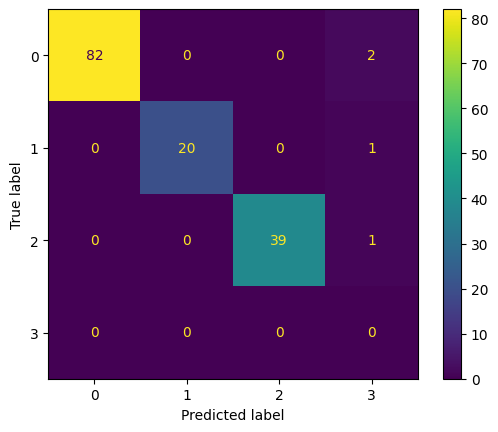

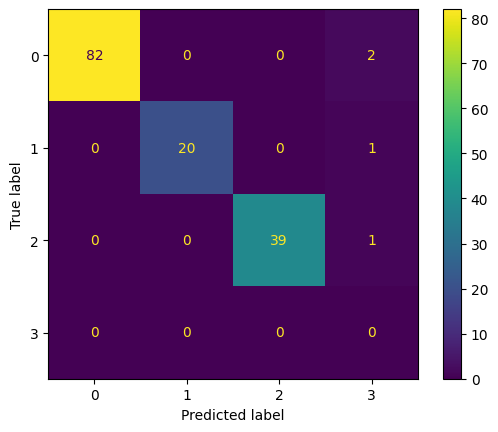

In [34]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot().figure_.savefig('results/detect/confusion_matrix.png')
disp.plot()

## attention


0: 640x640 1 Hymenoptera, 885.9ms
Speed: 16.9ms preprocess, 885.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


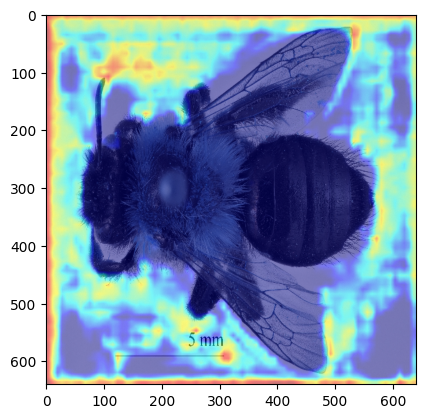

In [36]:
model = YOLO("./runs/detect/train10/weights/best.pt") 
model = model.cpu()

target_layers = [model.model.model[16]]

img = cv2.imread('images/hymenoptera.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

cam = EigenCAM(model, target_layers, task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.savefig('results/detect/cam.png')
plt.show()

In [8]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (m): ModuleList(
          (0): Bottleneck(
            (cv1): Conv(
              (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
            )
            (cv2): Conv(
              (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
    